In [1]:
#Reference
#https://colab.research.google.com/drive/1Xy1ArMT53FvU9Prr10Txk4Y93h-JvcLI#scrollTo=gH91uYun3Z62

**Routing:**

Routing is the pattern where a classifier inspects the input and you send it down one of several specialised branches.

Used to send a request to the correct specialist agent
(e.g., Python, SQL, ML MCQ generators).

**Parallelism:**
Used when multiple independent tasks can run together
(e.g., generating Easy, Medium, and Hard MCQs simultaneously).

Then an aggregator combines the outputs into the final result.

In [2]:
#Splitting into a router + specialised handlers means each handler has a focused prompt

In [3]:
!pip install langchain langchain-groq langgraph python-dotenv ipython --quiet

In [4]:
import os
from dotenv import load_dotenv
load_dotenv('/content/.env.txt')
print("Keys loaded:", "GROQ_API_KEY")

Keys loaded: GROQ_API_KEY


In [5]:
import os, time
from pathlib import Path
from typing import TypedDict, Annotated
from typing_extensions import Literal
import operator

from pydantic import BaseModel, Field
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

In [6]:
from pathlib import Path
from IPython.display import Image, display, Markdown

OUT = Path("graph_out_routing")
OUT.mkdir(exist_ok=True)

def save_graph(app, name):
    graph = app.get_graph()

    (OUT / f"{name}.mmd").write_text(graph.draw_mermaid())

    try:
        (OUT / f"{name}.png").write_bytes(graph.draw_mermaid_png())
        print(f"Saved: {name}.png")
    except Exception:
        print("PNG generation failed")

def show_graph(name):
    png = OUT / f"{name}.png"

    if png.exists():
        display(Image(filename=png))
    else:
        display(Markdown(f"Open `graph_out_routing/{name}.mmd` in mermaid.live"))

In [7]:
import os
os.listdir("graph_out_routing")  #now empty, when we call it later both files png+mmd will be saved

['09_routing_command.png',
 '09_routing_conditional.png',
 '09_routing_command.mmd',
 '09_routing_conditional.mmd',
 '09_routing_conditional1.png',
 '09_routing_conditional1.mmd']

In [8]:
# Initialize Groq model
from langchain.chat_models import init_chat_model

In [9]:
llm = init_chat_model(
    "groq:llama-3.3-70b-versatile",
    temperature=0
)

print("LLM ready")

LLM ready


**2.The router schema**

Use with_structured_output and Literal so the LLM is constrained to one of the allowed labels. If it tried to return anything else, validation would fail.

In [10]:
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(description="The next step in the routing process.")

router = llm.with_structured_output(Route)
print(router.invoke([
    SystemMessage(content="Route the input to story, joke, or poem based on the user's request."),
    HumanMessage(content="Write me a joke about Jolly"),
]))


step='joke'


**3.Graph API: add_conditional_edges style**

Three terminal worker nodes, one router node, one conditional edge from the router to the right worker.

Saved: 09_routing_conditional.png


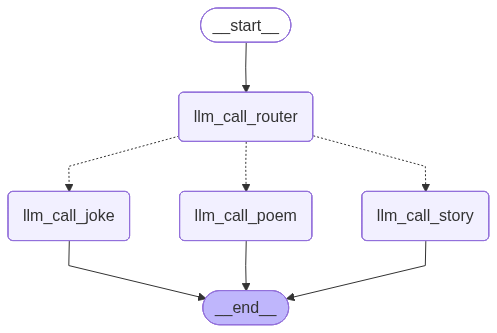

'Graph-level conditional edges'

In [11]:
# Way-1
class State(TypedDict):
    input: str
    decision: str
    output: str

def llm_call_story(state: State):
    return {"output": llm.invoke(f"Write a 2 sentence story: {state['input']}").content}

def llm_call_joke(state: State):
    return {"output": llm.invoke(f"Write a one line joke: {state['input']}").content}

def llm_call_poem(state: State):
    return {"output": llm.invoke(f"Write a 4 line poem: {state['input']}").content}

'''

def llm_call_router(state: State):
    decision = router.invoke([
        SystemMessage(content="Route the input to story, joke, or poem based on the user's request."),
        HumanMessage(content=state["input"]),
    ])
    print(f"[router] picked: {decision.step}")
    return {"decision": decision.step}
'''

def llm_call_router(state: State):
    decision = router.invoke([
        SystemMessage(content="Route the input to story, joke, or poem based on the user's request."),
        HumanMessage(content=state["input"]),
    ])
    # works whether decision is a dict or Pydantic object
    step = decision["step"] if isinstance(decision, dict) else decision.step
    return {"decision": step}


def route_decision(state: State):
    return {"story": "llm_call_story", "joke": "llm_call_joke", "poem": "llm_call_poem"}[state["decision"]]

builder = StateGraph(State)
builder.add_node("llm_call_router", llm_call_router)
builder.add_node("llm_call_story", llm_call_story)
builder.add_node("llm_call_joke", llm_call_joke)
builder.add_node("llm_call_poem", llm_call_poem)

builder.add_edge(START, "llm_call_router")
builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {"llm_call_story": "llm_call_story",
     "llm_call_joke": "llm_call_joke",
     "llm_call_poem": "llm_call_poem"},
)
builder.add_edge("llm_call_story", END)
builder.add_edge("llm_call_joke", END)
builder.add_edge("llm_call_poem", END)

app = builder.compile()
save_graph(app, "09_routing_conditional")
show_graph("09_routing_conditional")

'''Graph-level conditional edges'''


In [12]:
#Testing of Routing Node
for prompt_text in ["Write me a joke about cats", "Tell me a short story about a robot", "A poem about coffee"]:
    result = app.invoke({"input": prompt_text, "decision": "", "output": ""})
    print(f"\n--- input: {prompt_text!r}")
    print(f"decision: {result['decision']}")
    print(f"output:   {result['output'][:20]}")

#AttributeError: 'dict' object has no attribute 'step'


--- input: 'Write me a joke about cats'
decision: joke
output:   Why did the cat join

--- input: 'Tell me a short story about a robot'
decision: story
output:   As the last star in 

--- input: 'A poem about coffee'
decision: poem
output:   Rich aroma fills the


In [13]:
#Test one at a time (simplest debug)
result = app.invoke({"input": "Write me a joke about cats", "decision": "", "output": ""})
print(result)  # prints full state dict — see everything at once

{'input': 'Write me a joke about cats', 'decision': 'joke', 'output': 'Why did the cat join a band, because it wanted to be the purr-cussionist.'}


In [14]:
#Stream steps (see each node firing)
for step in app.stream({"input": "Write me a joke about ChatGpt and CLAUDE", "decision": "", "output": ""}):
    print(step)  # prints output of each node as it runs

{'llm_call_router': {'decision': 'joke'}}
{'llm_call_joke': {'output': 'Why did ChatGpt and CLAUDE go to therapy, because they were struggling to process their differences and it was a real AI-dentity crisis.'}}


Saved: 09_routing_conditional1.png


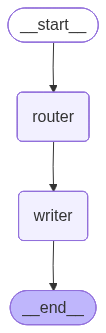

'State-level dict lookup'

In [15]:
#way-2
# --- State ---
class State(TypedDict):
    input: str
    decision: str
    output: str

# --- Router ---
class Route(TypedDict):
    step: Literal["story", "joke", "poem"]

router = llm.with_structured_output(Route)

PROMPTS = {
    "story": "Write a 2 sentence story: {}",
    "joke":  "Write a one line joke: {}",
    "poem":  "Write a 4 line poem: {}",
}

# --- Nodes ---
def llm_router(state: State):
    decision = router.invoke([
        SystemMessage(content="Route the input to story, joke, or poem based on the user's request."),
        HumanMessage(content=state["input"]),
    ])
    return {"decision": decision["step"]}

def llm_writer(state: State):
    prompt = PROMPTS[state["decision"]].format(state["input"])
    return {"output": llm.invoke(prompt).content}

# --- Graph ---
builder = StateGraph(State)
builder.add_node("router", llm_router)
builder.add_node("writer", llm_writer)

builder.add_edge(START, "router")
builder.add_edge("router", "writer")  # no conditional needed — decision is in state
builder.add_edge("writer", END)

app1 = builder.compile()
save_graph(app1, "09_routing_conditional1")
show_graph("09_routing_conditional1")

'''State-level dict lookup'''


**The routing now happens inside the writer node via state["decision"], not at the graph level. This is the right call when all branches do the same kind of work.**

**4.Same thing with Command** (no add_conditional_edges)
Modern style. The router returns Command(goto=...) directly. No separate route_decision function.

In [17]:
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(description="The next step in the routing process.")

router = llm.with_structured_output(Route)
print(router.invoke([
    SystemMessage(content="Route the input to story, joke, or poem based on the user's request."),
    HumanMessage(content="Write me a joke about Jolly"),
]))

step='joke'


Saved: 09_routing_command.png


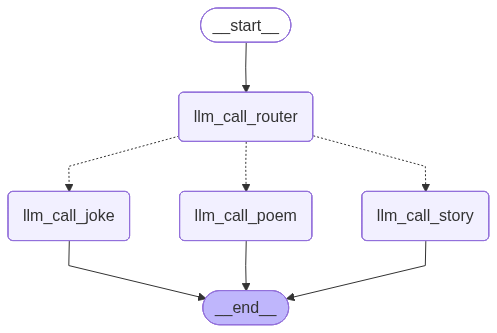

[router] picked: poem
Jolly Gupta, a name so bright,
Shines with kindness, day and night.
With a heart full of joy and glee,
Jolly Gupta spreads happiness wild and free.


In [20]:
def llm_call_router_cmd(state: State) -> Command[Literal["llm_call_story", "llm_call_joke", "llm_call_poem"]]:
    decision = router.invoke([
        SystemMessage(content="Route the input to story, joke, or poem based on the user's request."),
        HumanMessage(content=state["input"]),
    ])
    print(f"[router] picked: {decision.step}")
    goto = {"story": "llm_call_story", "joke": "llm_call_joke", "poem": "llm_call_poem"}[decision.step]
    return Command(update={"decision": decision.step}, goto=goto)

builder2 = StateGraph(State)
builder2.add_node("llm_call_router", llm_call_router_cmd)
builder2.add_node("llm_call_story", llm_call_story)
builder2.add_node("llm_call_joke", llm_call_joke)
builder2.add_node("llm_call_poem", llm_call_poem)

builder2.add_edge(START, "llm_call_router")
builder2.add_edge("llm_call_story", END)
builder2.add_edge("llm_call_joke", END)
builder2.add_edge("llm_call_poem", END)

app2 = builder2.compile()
save_graph(app2, "09_routing_command")
show_graph("09_routing_command")

print(app2.invoke({"input": "a poem about Jolly Gupta", "decision": "", "output": ""})["output"])

**5. LLM router vs deterministic router**
Routers do not have to use an LLM.

# Router Types in Agentic AI / LangGraph

A **router** decides which path (node/agent/tool) should handle the user's request.

---

## 1. Hard Rules / Regex

### When to Use
Use when the input follows a **known and predictable format**.

### Example

User input:

```text
joke: cats
```

Router:

```python
if text.startswith("joke:"):
    return "joke"
```

### Real-Life Analogy

A security guard checks:

```text
Employee Card  → Office Entry
Visitor Pass   → Reception
```

No intelligence required—just rules.

### Pros

- Fastest
- Cheapest
- Easy to maintain

### Cons

- Not flexible
- Breaks when users phrase things differently

---

## 2. Small Classifier Model

### When to Use

Use when you have:

- Labeled training data
- High traffic
- Latency and cost concerns

### Example

Training data:

```text
"Tell me a joke"      → Joke
"Write a story"       → Story
"A poem about coffee" → Poem
```

User:

```text
Make me laugh
```

Classifier predicts:

```text
Joke
```

### Real-Life Analogy

A junior employee trained using many examples.

### Pros

- Fast
- Cheap
- More flexible than rules

### Cons

- Needs training data
- Limited reasoning ability

---

## 3. LLM with Structured Output

### When to Use

Use when:

- User inputs are messy
- Natural language understanding is required
- Route labels are stable

### Example

User:

```text
I had a terrible day. Cheer me up.
```

LLM understands intent:

```json
{
  "step": "joke"
}
```

### Real-Life Analogy

An experienced receptionist who understands what customers mean, even when they don't use exact words.

### Pros

- Handles natural language well
- Easy to extend
- No training data needed

### Cons

- Higher cost
- Slower than rules/classifiers

---

## 4. LLM + LLM Judge

### When to Use

Use when routing mistakes are expensive.

### Example

```text
User Question
      ↓
 Router LLM
      ↓
 Selected Route
      ↓
 Judge LLM
      ↓
 Approve / Reject
```

If the judge disagrees:

```text
Re-route request
```

### Real-Life Analogy

Receptionist makes a decision, then a manager double-checks before sending the customer.

### Pros

- Highest routing accuracy
- Reduces costly mistakes

### Cons

- Most expensive
- Slowest option

---

# Quick Selection Guide

| Situation | Best Router |
|------------|------------|
| Known patterns, prefixes, commands | Hard Rules / Regex |
| Lots of labeled examples | Small Classifier |
| Messy natural language | LLM Router |
| Expensive mistakes | LLM + Judge |

---

# Memory Trick

```text
Known Pattern     → Rules
Training Data     → Classifier
Natural Language  → LLM Router
High Risk         → LLM + Judge
```

---

# Important LangGraph Concept

No matter which router you choose:

```text
START
  ↓
Router
  ↓
Conditional Edge
  ↓
Story | Joke | Poem
  ↓
END
```

The **graph structure stays the same**.

Only the logic inside the router changes.